<br>
<br>
<div>
<img  style="float: left; padding-right: 100px; width: 350px" src="logai.png">
    </div>
    <br>
    <h2 align="center">LogAI</h2>
<hr>
<h4 align="center"><a href="https://t.co/IoL5C0LiPX">Zephania Reuben</a></h4>
<h4 align="center">September, 2025</h4>
<hr>
<h3 align="center">AfriAI Lab - ADVANCED AI SHORT COURSE TRAINING 2025
<br>
<hr>
ML4: END-END PROJECT | HOUSE PRICE PREDICTION
</h3>
<hr>
<br>

In [1]:
# import the important libraries
import pandas as pd
import matplotlib
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

In [2]:
# import/ load the data
housing = pd.read_csv("/content/housing.csv")

In [3]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
housing["ocean_proximity"].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


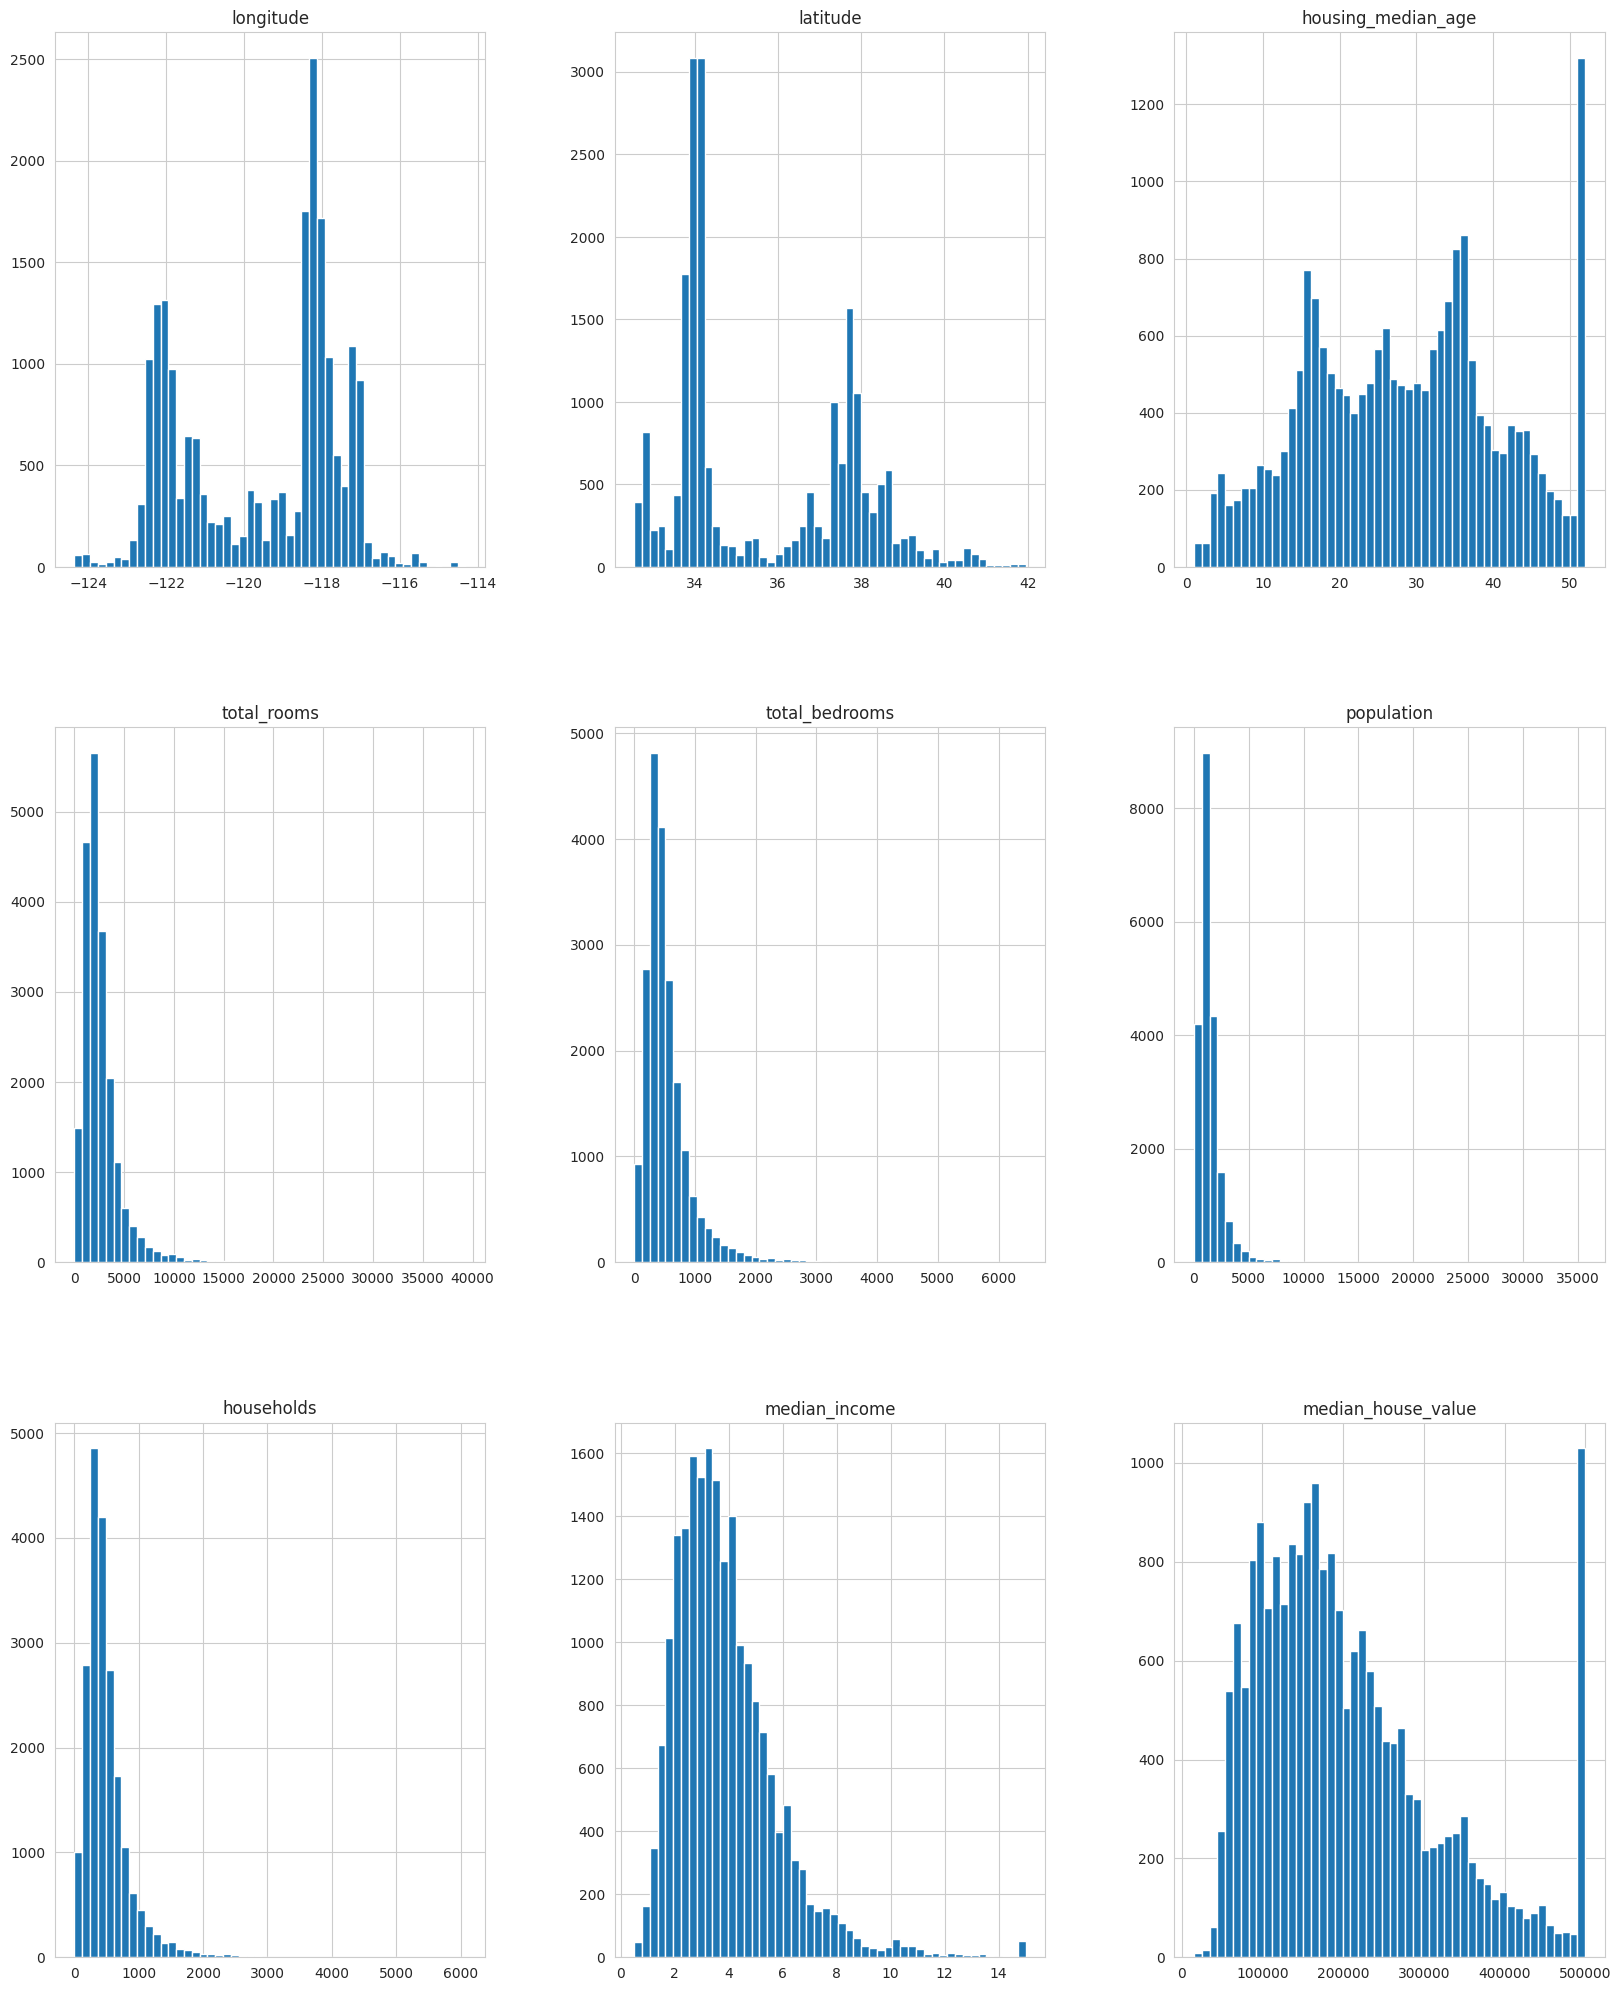

In [6]:
# Also you can describe the data using histogram
# which draws y-(number of instances) against x-(attribute in the dataset)

import seaborn as sns
sns.set_style('whitegrid')
housing.hist(bins=50, figsize=(20,25))
plt.show()

In [7]:
# also you can use sklearn funcion to split train and test sets
from sklearn.model_selection import train_test_split
train_data,test_data = train_test_split(housing, test_size=0.2,random_state=1950)

In [8]:
print("The shape of train set is : ",train_data.shape)
print("The shape of the test set is : ",test_data.shape)

The shape of train set is :  (16512, 10)
The shape of the test set is :  (4128, 10)


In [9]:
train_data.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [10]:
train_data_num = train_data[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']]

In [11]:
#It is important to look for the very important attribute by viewing the
# correlation between attribute and look for the data
# craete a correlation matrix

corr_matrix = train_data_num.corr()

In [12]:
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924966,-0.105433,0.041180,0.067256,0.096160,0.052660,-0.022909,-0.050163
latitude,-0.924966,1.000000,0.008211,-0.030669,-0.062460,-0.102578,-0.066238,-0.073444,-0.140479
housing_median_age,-0.105433,0.008211,1.000000,-0.361659,-0.322329,-0.296753,-0.303991,-0.120259,0.107288
total_rooms,0.041180,-0.030669,-0.361659,1.000000,0.932177,0.858172,0.920604,0.197825,0.131092
total_bedrooms,0.067256,-0.062460,-0.322329,0.932177,1.000000,0.876408,0.979180,-0.006078,0.048862
population,0.096160,-0.102578,-0.296753,0.858172,0.876408,1.000000,0.906111,0.006900,-0.027052
households,0.052660,-0.066238,-0.303991,0.920604,0.979180,0.906111,1.000000,0.015144,0.064782
median_income,-0.022909,-0.073444,-0.120259,0.197825,-0.006078,0.006900,0.015144,1.000000,0.686806
median_house_value,-0.050163,-0.140479,0.107288,0.131092,0.048862,-0.027052,0.064782,0.686806,1.000000


<Axes: >

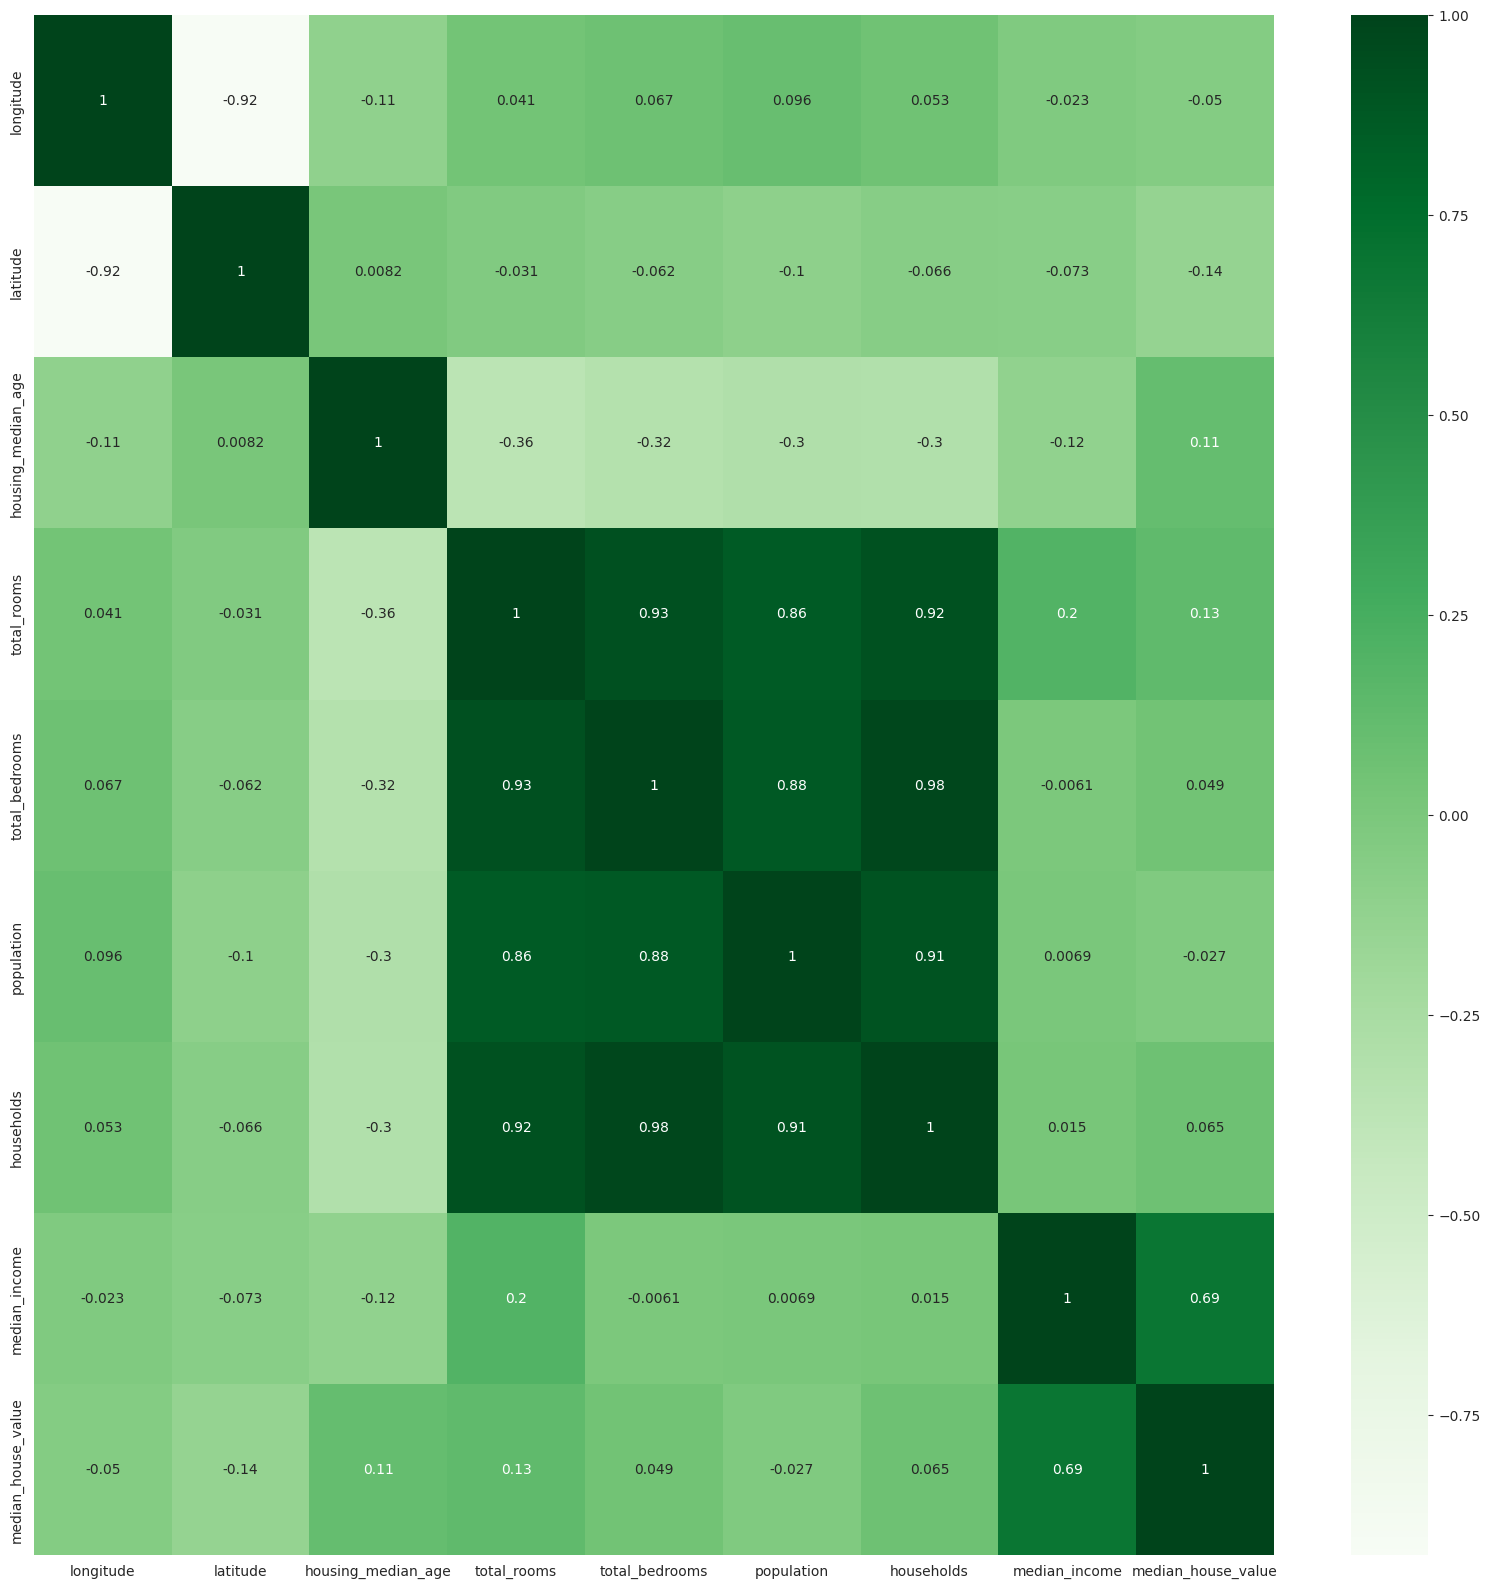

In [13]:
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix, annot=True, cmap='Greens')

In [14]:
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.686806
total_rooms,0.131092
housing_median_age,0.107288
households,0.064782
total_bedrooms,0.048862
population,-0.027052
longitude,-0.050163
latitude,-0.140479


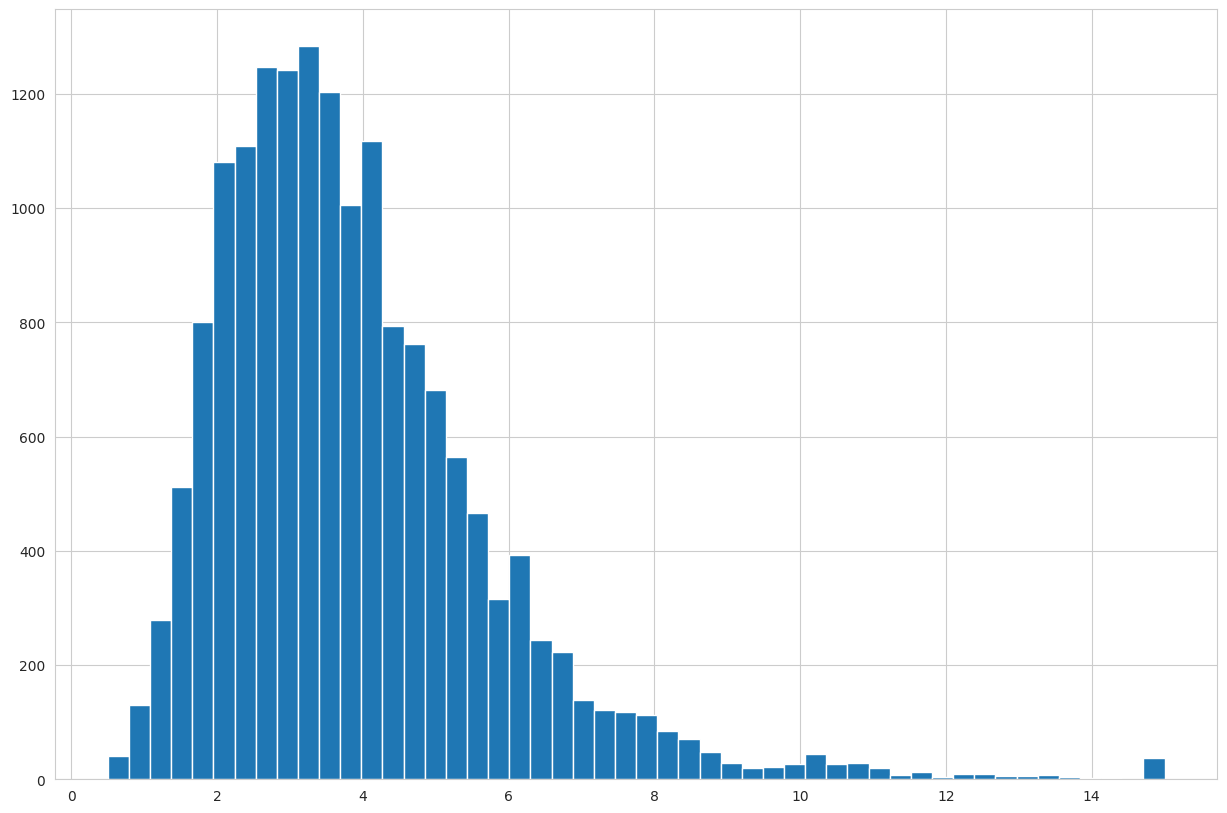

In [15]:
# it can be seen that median income have greater effect on the average median_house_value
# form there we can look if it is almost equally distributed amoung trainig and
# test set
train_data["median_income"].hist(bins=50,figsize=(15,10))
plt.show()

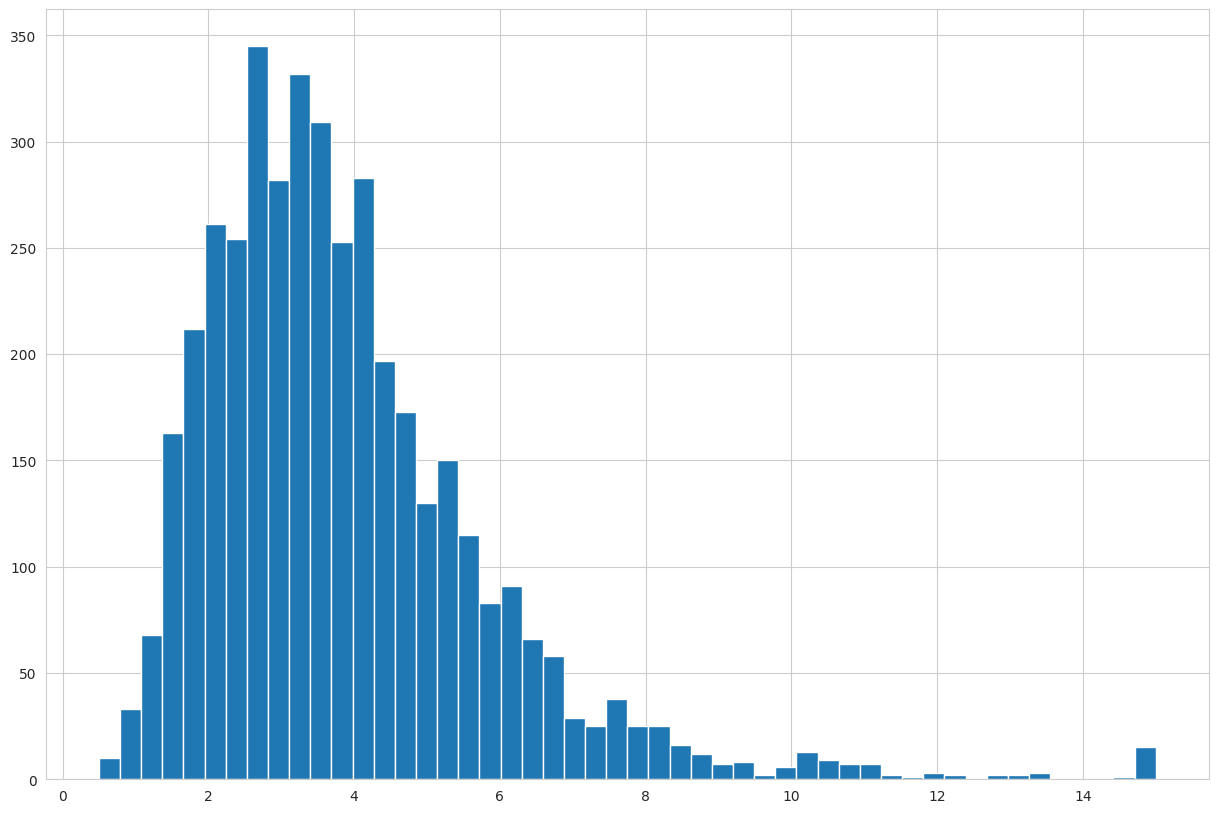

In [16]:
test_data["median_income"].hist(bins=50,figsize=(15,10))
plt.show()

In [17]:
# it seems some how there is equal distribution of median_income
# then try to count individual distinct values
np.ceil((train_data["median_income"])).value_counts()

,count
median_income,
4.0,4118
3.0,3959
5.0,2906
2.0,1809
6.0,1709
7.0,930
8.0,408
9.0,226
1.0,127


In [18]:
np.ceil((test_data["median_income"])).value_counts()

,count
median_income,
4.0,1032
3.0,987
5.0,692
2.0,489
6.0,418
7.0,233
8.0,101
9.0,57
11.0,33


In [19]:
housing['median_income']

,median_income
0,8.3252
1,8.3014
2,7.2574
3,5.6431
4,3.8462
...,...
20635,1.5603
20636,2.5568
20637,1.7000
20638,1.8672


In [20]:
# try to create strata from the group of median_income and apply stratified sampling
# to the data so that both traing and test set have equal somples of median_income for the \
# respective strate, to avoid sampling bias for this attribute
# ceil and divide by 1.5 to reduce the range of values in median_income
housing["income_cat"]= np.ceil(housing["median_income"]/1.5)
housing["income_cat"].where(housing["income_cat"]<5,5,inplace=True)

/tmp/ipykernel_746/3469148815.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["income_cat"].where(housing["income_cat"]<5,5,inplace=True)


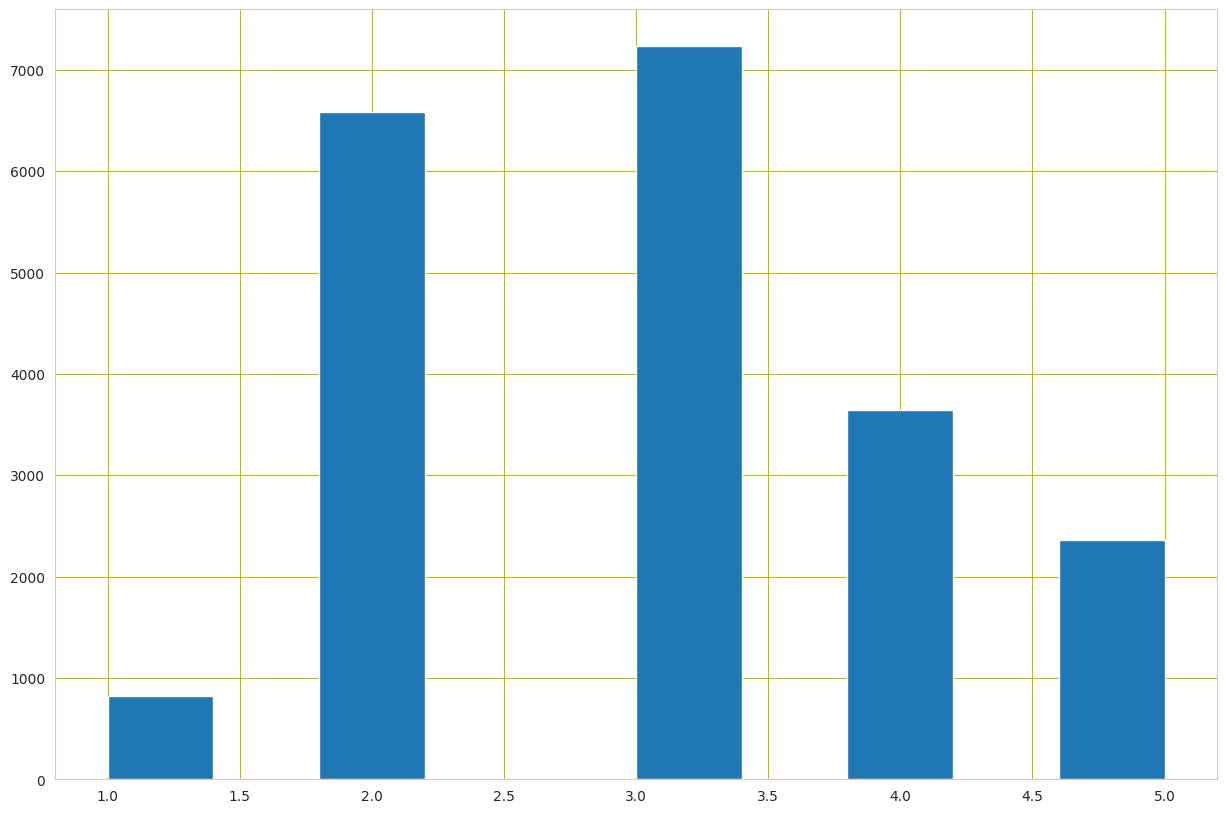

In [21]:
housing["income_cat"].hist(bins=10, figsize=(15,10))
plt.grid(c="y")
plt.show()

In [22]:
# it can be seen there are five groups there groups have to be almost equal distributed to
# training and testing set to avoid the effect of data imbalance and sampling bias
# import sklearn class for stratified sampling
from sklearn.model_selection import StratifiedShuffleSplit

split= StratifiedShuffleSplit(n_splits=1,random_state=50,test_size=0.2)

for train_indeces,test_indeces in split.split(housing,housing["income_cat"]):
    strat_train_data=housing.loc[train_indeces]
    strat_test_data= housing.loc[test_indeces]

In [23]:
print("The shape of train set is : ",strat_train_data.shape)
print("The shape of the test set is : ",strat_test_data.shape)

The shape of train set is :  (16512, 11)
The shape of the test set is :  (4128, 11)


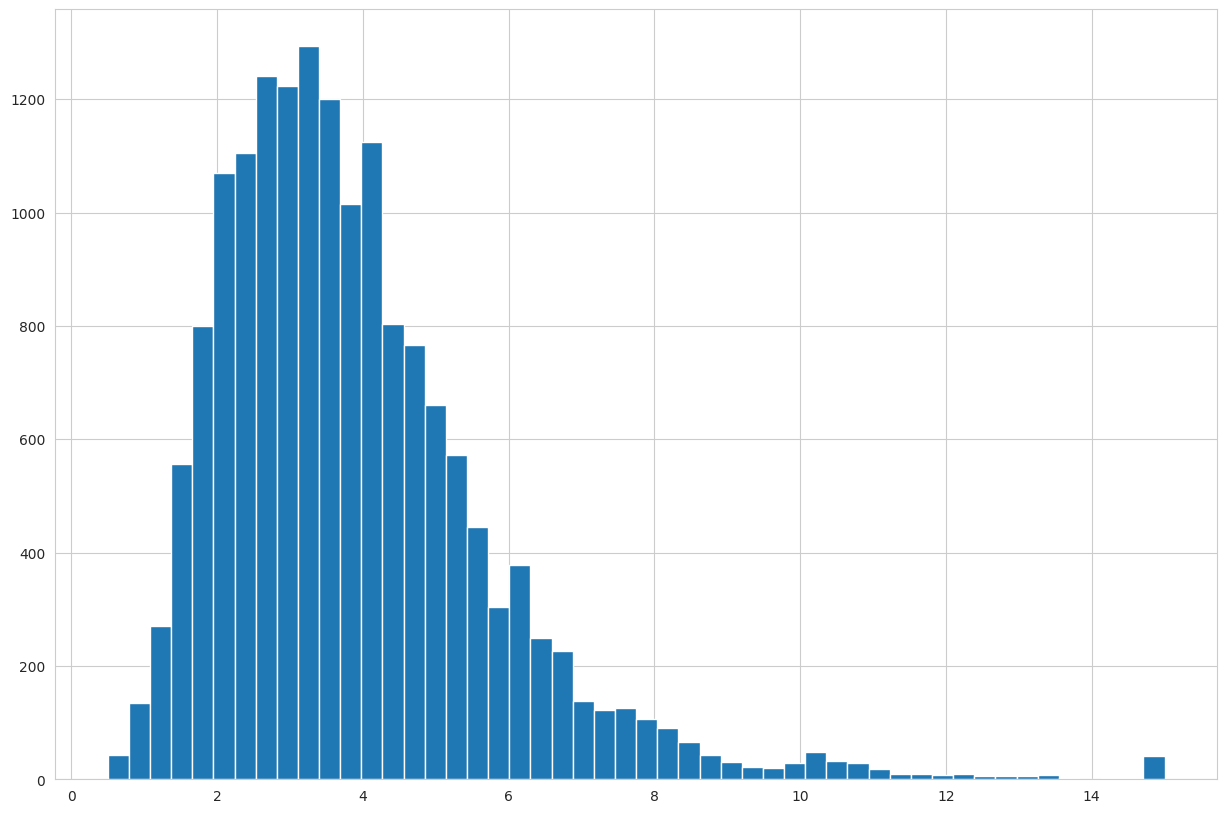

In [24]:
strat_train_data["median_income"].hist(bins=50,figsize=(15,10))
plt.show()

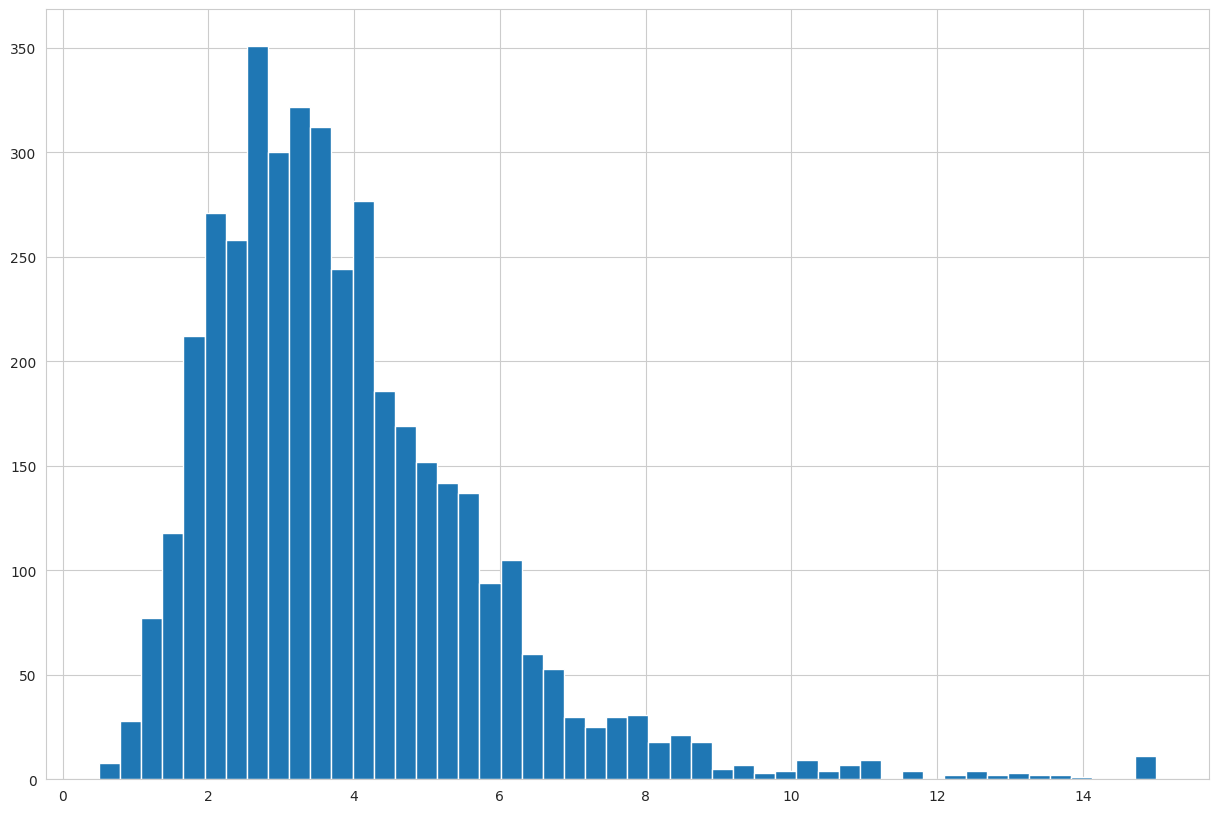

In [25]:
strat_test_data["median_income"].hist(bins=50,figsize=(15,10))
plt.show()

In [26]:
housing.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'income_cat'],
      dtype='object')

In [27]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3.0


In [28]:
# then after performing stratified sampling delete the created column
# income_cat

for i in strat_train_data,strat_test_data:
    i.drop("income_cat",inplace=True,axis=1)

In [29]:
len(strat_train_data.columns)

10

In [30]:
# the next thing is to visualize the data
# create a copy of training data set and call it housing
housing = strat_train_data.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

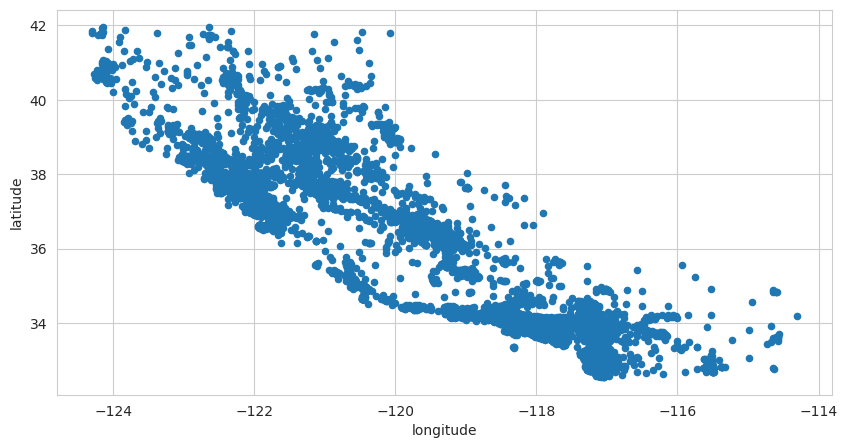

In [31]:
# plot a scatter plot to view data scattering
housing.plot(kind="scatter",x="longitude",y="latitude",figsize=(10,5))#,alpha=.1#)

<Axes: xlabel='longitude', ylabel='latitude'>

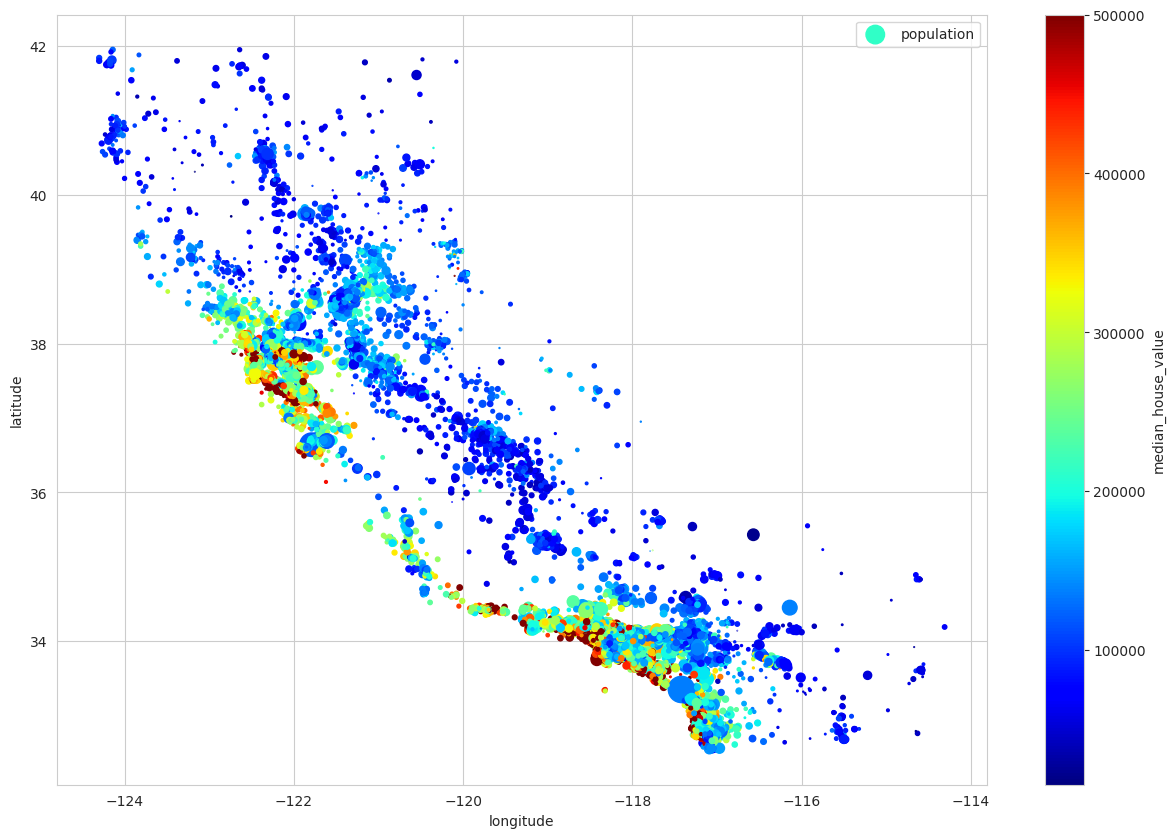

In [32]:
housing.plot(kind="scatter",x="longitude",y="latitude",c="median_house_value",
             s=housing["population"]/100,label="population",
             figsize=(15,10),cmap=plt.get_cmap("jet"),colorbar=True)

In [33]:
housing.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
10857,-117.86,33.71,21.0,1795.0,406.0,2246.0,400.0,3.1520,152800.0,<1H OCEAN
7043,-118.08,33.94,21.0,3933.0,949.0,2219.0,820.0,2.4926,171400.0,<1H OCEAN
14415,-117.24,32.79,18.0,2539.0,616.0,964.0,526.0,3.4306,275000.0,NEAR OCEAN
4108,-118.37,34.13,28.0,4287.0,627.0,1498.0,615.0,8.5677,500001.0,<1H OCEAN
3721,-118.43,34.20,28.0,3386.0,NaN,2240.0,737.0,3.0221,290100.0,<1H OCEAN


In [37]:
# again check for correlation between variables

corr_mat = housing.corr()

ValueError: could not convert string to float: '<1H OCEAN'

In [38]:
corr_mat["median_house_value"].sort_values(ascending=False)

NameError: name 'corr_mat' is not defined

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

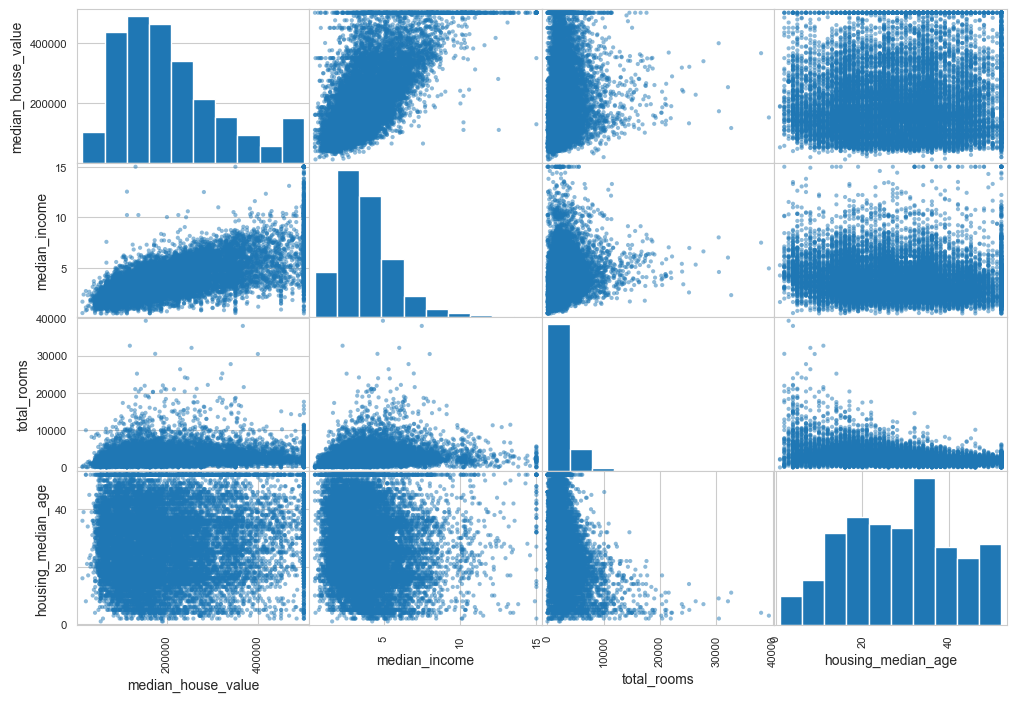

In [ ]:
# plot a scatter matrix to see the tendency of growth of attributes \
# with respect to other
# it basically plots every numerical attribute against every other numerical attribute
# because there are 10 attrib then we will have 10^2 plots = 100 which basical will not fit the page
# draw for few attributes
from pandas.plotting import scatter_matrix
attributes =["median_house_value","median_income","total_rooms","housing_median_age"]
scatter_matrix(housing[attributes],figsize=(12,8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

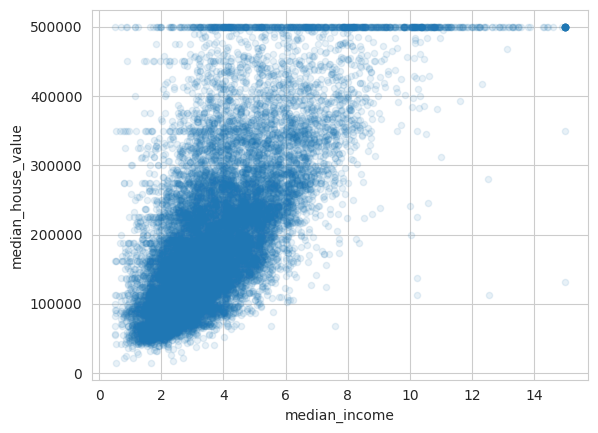

In [39]:
# the most promising attribute to predict the median house value is the median income
# so lets zoom in on their correlation scatterplot

housing.plot(kind="scatter",x="median_income",y="median_house_value",alpha=.1)

In [ ]:
# it can be seen the correlation is very strong
# you can clearly see the upward trend and the points are not too dispersed

In [40]:
housing_ = housing[['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value']]

In [41]:
# then it can be seen that median_income and total_rooms have great
# correlation to the median_house_value
# we can try combining features to see if we can get a feature which
# greatly correlate with the target data
# create some combined attributes

housing_["rooms_per_household"]=housing_["total_rooms"]/housing_["households"]
housing_["bedrooms_per_room"]=housing_["total_bedrooms"]/housing_["total_rooms"]

In [42]:
# check corretion agian

corr_matrix= housing_.corr()

In [43]:
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.686977
rooms_per_household,0.151376
total_rooms,0.137150
housing_median_age,0.103604
households,0.066519
total_bedrooms,0.052712
population,-0.024756
longitude,-0.048672
latitude,-0.140515


In [44]:
housing_.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room
longitude,1.000000,-0.924749,-0.106166,0.045996,0.070268,0.101034,0.057820,-0.017114,-0.048672,-0.030626,0.091763
latitude,-0.924749,1.000000,0.007768,-0.037873,-0.069053,-0.109485,-0.073801,-0.075884,-0.140515,0.108138,-0.114785
housing_median_age,-0.106166,0.007768,1.000000,-0.362436,-0.321229,-0.295312,-0.304196,-0.117417,0.103604,-0.148152,0.133390
total_rooms,0.045996,-0.037873,-0.362436,1.000000,0.929699,0.854845,0.918266,0.201923,0.137150,0.126575,-0.186893
total_bedrooms,0.070268,-0.069053,-0.321229,0.929699,1.000000,0.877928,0.980593,-0.005833,0.052712,-0.002269,0.088249
population,0.101034,-0.109485,-0.295312,0.854845,0.877928,1.000000,0.906528,0.005723,-0.024756,-0.071977,0.040203
households,0.057820,-0.073801,-0.304196,0.918266,0.980593,0.906528,1.000000,0.014245,0.066519,-0.080124,0.069084
median_income,-0.017114,-0.075884,-0.117417,0.201923,-0.005833,0.005723,0.014245,1.000000,0.686977,0.316942,-0.619691
median_house_value,-0.048672,-0.140515,0.103604,0.137150,0.052712,-0.024756,0.066519,0.686977,1.000000,0.151376,-0.255905
rooms_per_household,-0.030626,0.108138,-0.148152,0.126575,-0.002269,-0.071977,-0.080124,0.316942,0.151376,1.000000,-0.401029


In [45]:
# data cleaning
# remove missing value if exists

housing = strat_train_data.drop("median_house_value",axis=1,inplace=False)

In [46]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
15513,-117.03,33.18,17.0,5391.0,886.0,2732.0,830.0,5.1771,<1H OCEAN
10111,-117.94,33.94,25.0,3250.0,546.0,1452.0,501.0,5.1084,<1H OCEAN
10002,-121.07,39.04,9.0,2374.0,372.0,884.0,333.0,4.5042,INLAND
16700,-120.61,35.10,17.0,2799.0,637.0,2015.0,592.0,3.0536,<1H OCEAN
19958,-119.32,36.21,29.0,1220.0,232.0,619.0,246.0,3.3125,INLAND


In [47]:
housing_labels=strat_train_data["median_house_value"].copy()

In [48]:
housing_labels.head()

,median_house_value
15513,212800.0
10111,303800.0
10002,206400.0
16700,143600.0
19958,78300.0


In [49]:
print("Training data set : ")
housing.tail()

Training data set : 


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
10857,-117.86,33.71,21.0,1795.0,406.0,2246.0,400.0,3.1520,<1H OCEAN
7043,-118.08,33.94,21.0,3933.0,949.0,2219.0,820.0,2.4926,<1H OCEAN
14415,-117.24,32.79,18.0,2539.0,616.0,964.0,526.0,3.4306,NEAR OCEAN
4108,-118.37,34.13,28.0,4287.0,627.0,1498.0,615.0,8.5677,<1H OCEAN
3721,-118.43,34.20,28.0,3386.0,NaN,2240.0,737.0,3.0221,<1H OCEAN


In [50]:
print("Labels are : ")
housing_labels.tail()

Labels are : 


,median_house_value
10857,152800.0
7043,171400.0
14415,275000.0
4108,500001.0
3721,290100.0


In [51]:
# data cleaning involves the removal of missing values
housing.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,162
population,0
households,0
median_income,0
ocean_proximity,0


In [ ]:
# it can be seen that thete are missing values on total_bedrooms colums
# we have to handle the missing values
# Missing values can be handled in three different ways
   # 1. removing the specific rows with missing values
   # 2. remove the colums which have missing values
   # 3. filling the missing values with
         # 1. mean
        # 2.median
        # 3. zero
# housing.dropna(subset=["total_rooms"])
# housing.drop("total_rooms",axis=1)
# housing.fillna(np.median(housing["total_rooms"]),inplace=True)

In [ ]:
#housing.fillna(np.median(housing["total_rooms"]),inplace=True)
#housing.tail()

In [ ]:
#housing.isna().sum()

In [52]:
# also we can use an SimpleImputer class
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

In [53]:
housing['ocean_proximity'].unique()

array(['<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'NEAR BAY', 'ISLAND'],
      dtype=object)

In [54]:
# to use imputer we have to remove the categorical data from
# our dataset
# remain with numerical
#housing store the ocean proximity info
housing_op= housing["ocean_proximity"].copy()
housing_num = housing.drop("ocean_proximity",axis=1)

In [55]:
housing_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
15513,-117.03,33.18,17.0,5391.0,886.0,2732.0,830.0,5.1771
10111,-117.94,33.94,25.0,3250.0,546.0,1452.0,501.0,5.1084
10002,-121.07,39.04,9.0,2374.0,372.0,884.0,333.0,4.5042
16700,-120.61,35.10,17.0,2799.0,637.0,2015.0,592.0,3.0536
19958,-119.32,36.21,29.0,1220.0,232.0,619.0,246.0,3.3125


In [56]:
# calculate the median // it calculates only for numerical values
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [57]:
imputer.statistics_# it returns the median value computed by the class

array([-118.5   ,   34.26  ,   29.    , 2131.    ,  435.    , 1166.    ,
        410.    ,    3.5385])

In [58]:
# we can compare them with the manually computed median
housing_num.median().values

array([-118.5   ,   34.26  ,   29.    , 2131.    ,  435.    , 1166.    ,
        410.    ,    3.5385])

In [59]:
# we can return the strategy used to obtain median
imputer.strategy

'median'

In [60]:
housing_num.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,162
population,0
households,0
median_income,0


In [61]:
# transfrom our training dataset by filling null values/missing values by median
X = imputer.transform(housing_num)

In [62]:
X

array([[-117.03  ,   33.18  ,   17.    , ..., 2732.    ,  830.    ,
           5.1771],
       [-117.94  ,   33.94  ,   25.    , ..., 1452.    ,  501.    ,
           5.1084],
       [-121.07  ,   39.04  ,    9.    , ...,  884.    ,  333.    ,
           4.5042],
       ...,
       [-117.24  ,   32.79  ,   18.    , ...,  964.    ,  526.    ,
           3.4306],
       [-118.37  ,   34.13  ,   28.    , ..., 1498.    ,  615.    ,
           8.5677],
       [-118.43  ,   34.2   ,   28.    , ..., 2240.    ,  737.    ,
           3.0221]])

In [63]:
# then convert the transformed dataset by passing the number of columns from the housing_num
housing_transformed = pd.DataFrame(X,columns=housing_num.columns)

In [64]:
housing_transformed.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-117.03,33.18,17.0,5391.0,886.0,2732.0,830.0,5.1771
1,-117.94,33.94,25.0,3250.0,546.0,1452.0,501.0,5.1084
2,-121.07,39.04,9.0,2374.0,372.0,884.0,333.0,4.5042
3,-120.61,35.10,17.0,2799.0,637.0,2015.0,592.0,3.0536
4,-119.32,36.21,29.0,1220.0,232.0,619.0,246.0,3.3125


In [65]:
housing_transformed.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0


In [66]:
housing_transformed.shape

(16512, 8)

In [67]:
housing_op.shape

(16512,)

In [69]:
housing["ocean_proximity"].unique()

array(['<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'NEAR BAY', 'ISLAND'],
      dtype=object)

In [70]:
# handling categorical data
# find the categorical data and apply LabelEncoder class
housing_cat = housing["ocean_proximity"]
#this change the categorical data to numerical values
label_encoder = LabelEncoder()
label_encoder.fit(housing_cat)

LabelEncoder()

In [71]:
label_encoder.classes_

array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)

In [73]:
#transform the categorical data
label_encoded=label_encoder.transform(housing_cat)

In [74]:
pd.DataFrame(data=label_encoded).value_counts()

,count
0,
0,7329
1,5224
4,2100
3,1855
2,4


In [75]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,7329
INLAND,5224
NEAR OCEAN,2100
NEAR BAY,1855
ISLAND,4


In [76]:
# also we can use OneHotEncoding
label_onehot = OneHotEncoder()

In [77]:

# find the fitting values using fit method
label_onehot.fit(label_encoded.reshape(-1,1))# any numbers of rows but only one column

OneHotEncoder()

In [78]:
#transform the the categorical data
label_onehot= label_onehot.transform(label_encoded.reshape(-1,1))

In [79]:
label_onehot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [80]:
label_onehot_array = label_onehot.toarray()

In [81]:
label_onehot_array.shape

(16512, 5)

In [82]:
label_onehot_array

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.]])

In [83]:
# Also we can use the LabelBinarizer class to change directly from
# categorical to OneHotEncoding
# create an object of LabelBinarizer
label_binarizer = LabelBinarizer()

In [84]:
# fit the data to the to get learned values to fit our data
# set then transform our dataset to numerical of [0,1]
label_binarizer.fit(housing_cat)

LabelBinarizer()

In [85]:
#transform the datasets
label_binarizer=label_binarizer.transform(housing_cat)

In [86]:
label_binarizer

array([[1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0],
       [1, 0, 0, 0, 0]])

In [87]:
# then the next thing is to perform features scalling
# This makes attribute to in the same range
# for the case of our data total_number of room
# look for the max and min values

In [88]:
np.array(housing["total_rooms"]).max()

np.float64(39320.0)

In [89]:
np.array(housing["total_rooms"]).min()

np.float64(2.0)

In [90]:
# the we need to have the same scale
# to avoid great variation/despersion
# Ways for features scalling
# 1. MinMaxSaler// normalization
  #xnew= x-xmin/xmax-xmin
# 2.StandardScaler // zero mean ans std=1
  #xnew = x-mean/std

In [91]:
# The use of transformation pipeline
# As it can be seen, there are many transformation procedures/steps that are needed to be executed
# sklearn provides Pipepline class to help combine the steps and apply them at one
# start with the removing null Pipeline and feature scaling
num_pipeline = Pipeline([
                       ("imputer",SimpleImputer(strategy="median")),# first transformation
                        ("std_scaler",StandardScaler()) # second transformation
                        ])

In [92]:
# then we can apply the transformation to our dataset
# find the fitting values the transform // apply for the numerical training set
# becouse the fit method can not calculate the fitting values for
# for the training dataset
housing_removed_null_scaled = num_pipeline.fit(housing_num)

In [93]:
#then transform the data set to get our dataset transformed according to the values
# obtained after fitting
housing_pipeline_transformed_num = housing_removed_null_scaled.transform(housing_num)

In [94]:
housing_pipeline_transformed_num

array([[ 1.26984606e+00, -1.14953667e+00, -9.29764518e-01, ...,
         1.13744581e+00,  8.60355835e-01,  6.90273303e-01],
       [ 8.15387415e-01, -7.93458151e-01, -2.95009189e-01, ...,
         1.87967941e-02,  2.22457241e-04,  6.54039242e-01],
       [-7.47750567e-01,  1.59601609e+00, -1.56451985e+00, ...,
        -4.77603705e-01, -4.38994587e-01,  3.35369381e-01],
       ...,
       [ 1.16497099e+00, -1.33226117e+00, -8.50420102e-01, ...,
        -4.07688142e-01,  6.55821364e-02, -2.30873524e-01],
       [ 6.00643219e-01, -7.04438523e-01, -5.69759412e-02, ...,
         5.89982430e-02,  2.98262594e-01,  2.47855869e+00],
       [ 5.70678913e-01, -6.71641817e-01, -5.69759412e-02, ...,
         7.07465093e-01,  6.17217828e-01, -4.46326418e-01]])

In [95]:
# try to change the dataset to pandas dataframe and observe the transform performed
housing_after_pipeline_one=pd.DataFrame(housing_pipeline_transformed_num,columns=housing_num.columns)

In [96]:
housing_after_pipeline_one.to_csv('../data/transformed.csv')

OSError: Cannot save file into a non-existent directory: '../data'

In [97]:
housing_after_pipeline_one.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,1.269846,-1.149537,-0.929765,1.260139,0.829915,1.137446,0.860356,0.690273
1,0.815387,-0.793458,-0.295009,0.279367,0.019681,0.018797,0.000222,0.654039
2,-0.747751,1.596016,-1.564520,-0.121920,-0.394967,-0.477604,-0.438995,0.335369
3,-0.518024,-0.249970,-0.929765,0.072768,0.236538,0.510828,0.238132,-0.429713
4,0.126208,0.270092,0.022368,-0.650557,-0.728593,-0.709199,-0.666446,-0.293162


In [98]:
housing_after_pipeline_one.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>, <Axes: >]],
      dtype=object)

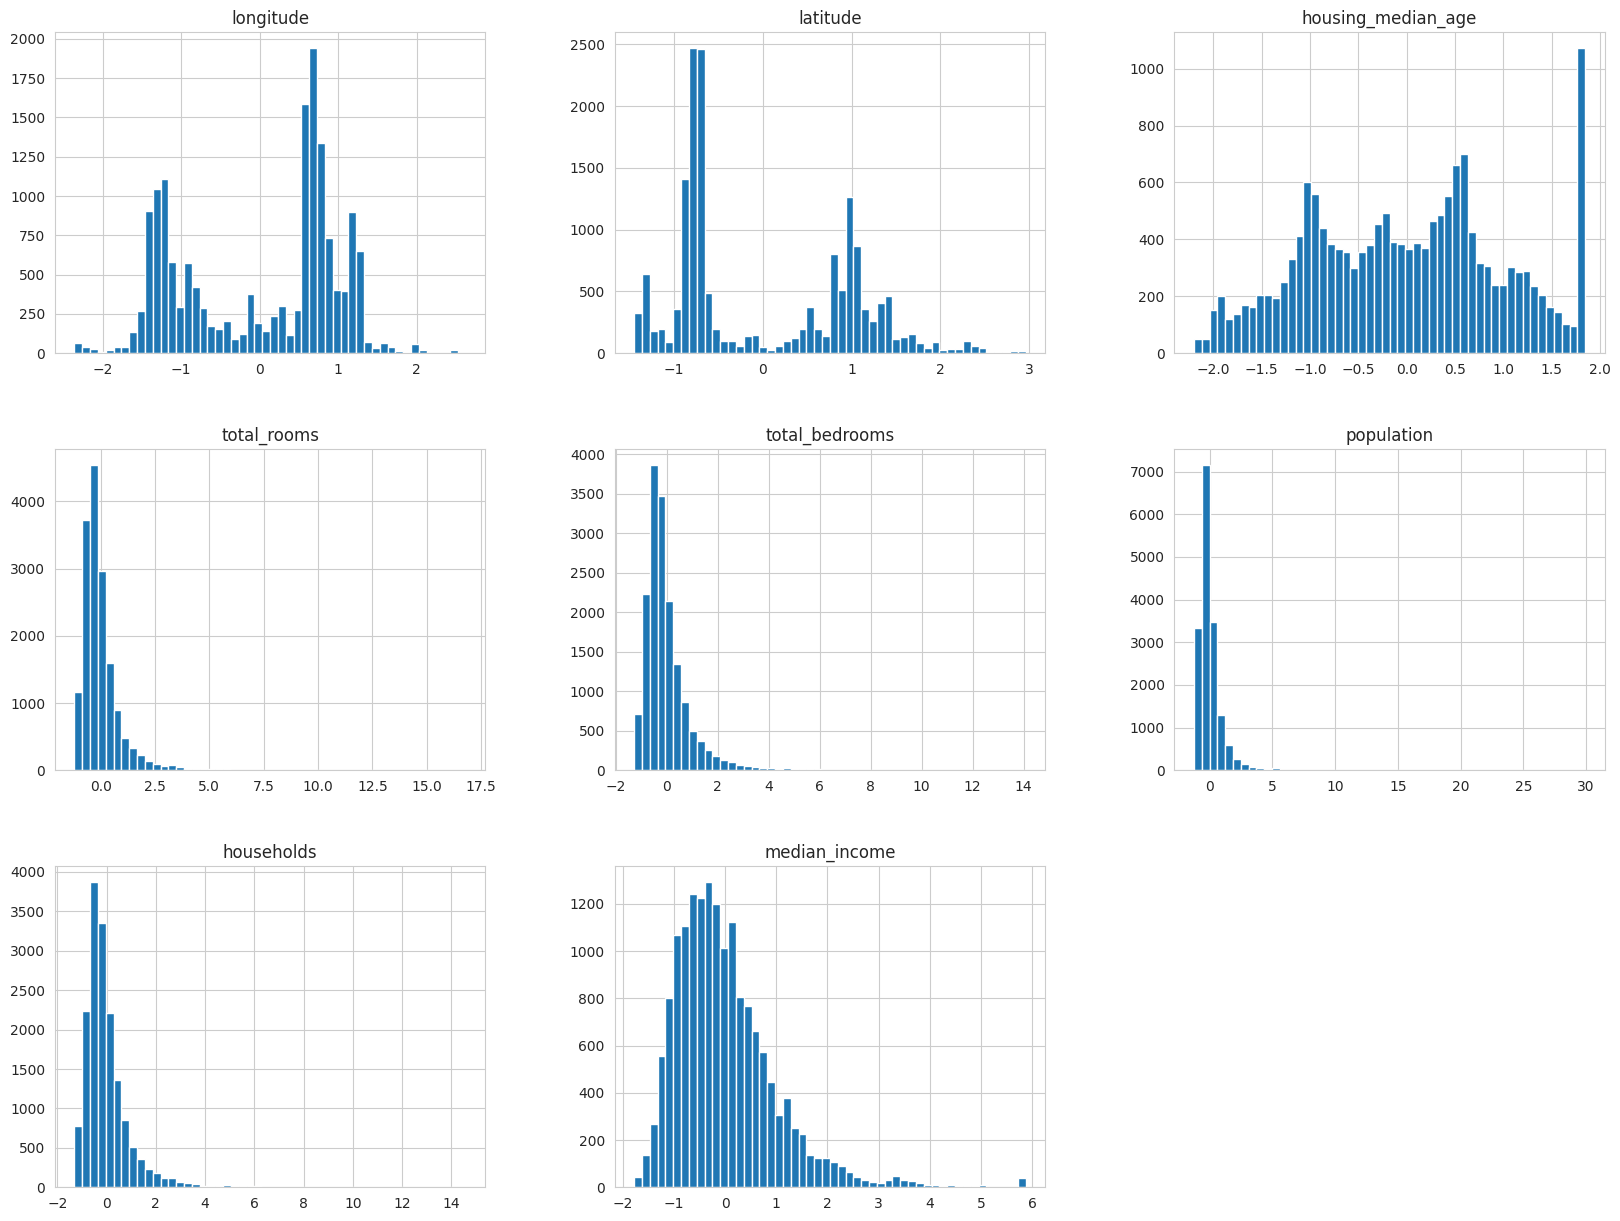

In [99]:
housing_after_pipeline_one.hist(bins=50, figsize=(20,15))

In [100]:
# lets transform the categorical data using Pipeline claa
cat_pipeline = Pipeline([("cat_num",LabelBinarizer())])

In [ ]:
# depresse fit and transform for LabelBinarize
#cat_obj_cat_pipeline = cat_pipeline.fit(housing_cat)

In [ ]:
# We need to avoid manually extraction of categorical and
# continous data so we can create a custome class which separates
# attribute to categorical and numerical when are passe

In [101]:
from sklearn.base import BaseEstimator , TransformerMixin
class DataFrameSelector(BaseEstimator,TransformerMixin):
    def __init__(self,attribute_names):
        self.attribute_names=attribute_names
    def fit(self,X,y=0):
        return self
    def transform(self,X):
        return X[self.attribute_names].values

In [ ]:
# create new pipeline for the numrical data involving automatic features selection
# selecting automatic numerical values and apply other transformation

In [102]:
#select attributes name for numerical data
# the create a pipeline for numerical data transformation
numerical_attrib = list(housing_num.columns)
categorical_attrib=["ocean_proximity"]
numerical_pipeline = Pipeline([
                             ("select_attributes",DataFrameSelector(numerical_attrib)),
                             ("imputer",SimpleImputer(strategy="median")),
                             ("std_scaler",StandardScaler())
                              ])

In [103]:
cat_pipeline = Pipeline([
                             ("select_attributes",DataFrameSelector(categorical_attrib)),
                             ('label_bin', LabelBinarizer()),
                             ("imputer",SimpleImputer(strategy="median")),
                             ("std_scaler",StandardScaler())
                              ])

In [104]:
cat_pipeline.fit(housing)

TypeError: LabelBinarizer.fit_transform() takes 2 positional arguments but 3 were given

In [105]:
# create pipeline for categorical data transformation
# but first we have to create custom transfomer due to deptesses LabelBinarizer
class CustomBinarizer(BaseEstimator,TransformerMixin):
    def __init__(self,sparse_output=False):
        self.sparse_output = sparse_output
    def fit(self,X,y=0):# first it was passing one argument now requires two
        return self
    def transform(self,X,y=None):# first it was passing one argument now requires two
        encode=LabelBinarizer(sparse_output=self.sparse_output)
        encode.fit(X)
        return encode.transform(X)


In [106]:
# Then create the pipeline for the categorical data
# when the ocean_proximity attribute is passes through DataFrameselector
# other numerical attribute will be droped
categorical_pipeline = Pipeline([
                                ("select_attrib",DataFrameSelector(categorical_attrib)),
                                ("encode_categorical",CustomBinarizer())
                                ])

In [107]:
# then combine the two Pipelines and apply one to the data set
from sklearn.pipeline import FeatureUnion
final_pipeline = FeatureUnion(transformer_list=[("numerical_pipeline",numerical_pipeline),
                                                ("categorical_pipeline",categorical_pipeline)
                                               ])

In [108]:
# apply the final combine transformations to the dataset at once
housing_prepared = final_pipeline.fit(housing)

In [109]:
housing_prepared_final=housing_prepared.transform(housing)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [110]:
housing_prepared_final.shape

(16512, 13)

In [111]:
# return the transformed prepared to pandas dataframe
# add the columns for the added values from OneHotEncoding(LabelBinarizer)
housing_prepared_df = pd.DataFrame(housing_prepared_final,
                                   columns=list(housing.columns)+["one","two","three","four"])

In [112]:
housing_prepared_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,one,two,three,four
0,1.269846,-1.149537,-0.929765,1.260139,0.829915,1.137446,0.860356,0.690273,1.0,0.0,0.0,0.0,0.0
1,0.815387,-0.793458,-0.295009,0.279367,0.019681,0.018797,0.000222,0.654039,1.0,0.0,0.0,0.0,0.0
2,-0.747751,1.596016,-1.564520,-0.121920,-0.394967,-0.477604,-0.438995,0.335369,0.0,1.0,0.0,0.0,0.0
3,-0.518024,-0.249970,-0.929765,0.072768,0.236538,0.510828,0.238132,-0.429713,1.0,0.0,0.0,0.0,0.0
4,0.126208,0.270092,0.022368,-0.650557,-0.728593,-0.709199,-0.666446,-0.293162,0.0,1.0,0.0,0.0,0.0


In [113]:
housing_prepared_df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
ocean_proximity,0
one,0


In [114]:
housing.loc[housing.ocean_proximity=="ISLAND"]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
8317,-118.32,33.34,52.0,996.0,264.0,341.0,160.0,2.7361,ISLAND
8315,-118.33,33.34,52.0,2359.0,591.0,1100.0,431.0,2.8333,ISLAND
8314,-118.32,33.35,27.0,1675.0,521.0,744.0,331.0,2.1579,ISLAND
8316,-118.32,33.33,52.0,2127.0,512.0,733.0,288.0,3.3906,ISLAND


In [115]:
# split small portion of the housing
small_data = housing.iloc[7500:8500]
small_labels= housing_labels.iloc[7500:8500]
#small_data_prepared = final_pipeline.fit(small_data)

In [116]:
small_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
463,-122.27,37.87,49.0,1350.0,368.0,707.0,350.0,2.8846,NEAR BAY
12479,-121.49,38.59,20.0,463.0,180.0,486.0,190.0,1.0313,INLAND
20462,-118.76,34.28,21.0,2786.0,342.0,1114.0,322.0,5.8578,<1H OCEAN
8317,-118.32,33.34,52.0,996.0,264.0,341.0,160.0,2.7361,ISLAND
20120,-120.41,37.88,16.0,744.0,141.0,311.0,122.0,4.4231,INLAND


In [117]:
small_data_prepared_final=final_pipeline.transform(small_data)

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [118]:
small_data_prepared_final.shape

(1000, 13)

In [119]:
small_data["ocean_proximity"].unique()

array(['NEAR BAY', 'INLAND', '<1H OCEAN', 'ISLAND', 'NEAR OCEAN'],
      dtype=object)

In [120]:
def display_score(scores):
    print("scores : \n",scores)
    print("The mean score : ",scores.mean())
    print("Standard deviation score :",scores.std())

In [ ]:
# RandomFirestRegressor

In [121]:
forest = RandomForestRegressor()

In [122]:
# then perform predictions
# first fit the model
forest.fit(housing_prepared_final,housing_labels)

RandomForestRegressor()

In [123]:
print("Prdiction from learned model are : ")
print(forest.predict(small_data_prepared_final)[:4])

Prdiction from learned model are : 
[202863.    89248.   264486.   396350.02]


In [124]:
print("The true values for the small data \n",list(small_labels[:4]))

The true values for the small data 
 [211300.0, 85000.0, 266300.0, 450000.0]


In [125]:
# #check for the accuracy of the model
print("Model accuracy is : ",forest.score(small_data_prepared_final,small_labels))

Model accuracy is :  0.9762172935582755


In [126]:
# find the mean square error of the model// the performance measurement // metric rmse
from sklearn.metrics import mean_squared_error
predictions = forest.predict(housing_prepared_final)
mse = np.sqrt(mean_squared_error(predictions,housing_labels))

In [127]:
mse

np.float64(18056.314806362567)

In [ ]:
# use cross validation also the forest model
score_forest = cross_val_score(forest,housing_prepared_final,housing_labels,cv=10,
                              scoring="neg_mean_squared_error")
forest_score = np.sqrt(-score_forest)

In [ ]:
display_score(forest_score)

scores : 
 [46340.17777855 50036.83574781 48934.77984036 50401.41771463
 46780.48818928 49159.95049396 47236.03585657 49125.42049983
 50628.17791677 47367.17965007]
The mean score :  48601.04636878108
Standard deviation score : 1480.6231850975385


In [ ]:
# This is much better: Random forest look very promising, However the score on the training set
# is still much lower than on validation sets, meaning the model is still overfitting the training set
# possible solution is to apply regularization or get more training data
# Also you can try other models like NN,SVM, without spending a lot of time tweaking the hyperparameters

In [ ]:
# you should save your models

In [ ]:
import joblib
joblib.dump(forest,"forest_model.pki")

['forest_model.pki']

In [ ]:
# Fine tuning the model
# Lets assume you have shortlist ofpromising models , you can need to fine tune them,
# There are various method to this

In [ ]:
# Grid searchs
from sklearn.model_selection import GridSearchCV
param_grid=[{"n_estimators":[3,10,30],"max_features":[2,4,6,8]},
            {"bootstrap":[False],"n_estimators":[3,10],"max_features":[2,3,4]}
           ]

In [ ]:
forest_hyperparamter=RandomForestRegressor()
grid_search = GridSearchCV(forest_hyperparamter,param_grid,cv=5, scoring="neg_mean_squared_error")
grid_search.fit(housing_prepared_final,housing_labels)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid=[{'max_features': [2, 4, 6, 8],
                          'n_estimators': [3, 10, 30]},
                         {'bootstrap': [False], 'max_features': [2, 3, 4],
                          'n_estimators': [3, 10]}],
             scoring='neg_mean_squared_error')

In [ ]:
grid_search.best_params_

{'max_features': 8, 'n_estimators': 30}

In [ ]:
# Since 8 and 30 are the maiximum values that were evaluated,
#yuo should probably try searching again with higher values, since the score may continue to improve

In [ ]:
# you can also get the best estimator directly
grid_search.best_estimator_

RandomForestRegressor(max_features=8, n_estimators=30)

In [ ]:
# Then we can get cross_validation results
cvres = grid_search.cv_results_

for mean_score, params in zip(cvres["mean_test_score"],cvres["params"]):
    print(np.sqrt(-mean_score),params)

63455.19153918058 {'max_features': 2, 'n_estimators': 3}
55547.46242619232 {'max_features': 2, 'n_estimators': 10}
52402.181731953555 {'max_features': 2, 'n_estimators': 30}
60039.3836555631 {'max_features': 4, 'n_estimators': 3}
52549.98322045488 {'max_features': 4, 'n_estimators': 10}
50313.996778209614 {'max_features': 4, 'n_estimators': 30}
58501.405963848534 {'max_features': 6, 'n_estimators': 3}
51900.56082716489 {'max_features': 6, 'n_estimators': 10}
49607.74907670313 {'max_features': 6, 'n_estimators': 30}
58388.549778366425 {'max_features': 8, 'n_estimators': 3}
51257.405196065185 {'max_features': 8, 'n_estimators': 10}
49578.177978511696 {'max_features': 8, 'n_estimators': 30}
62195.939314663396 {'bootstrap': False, 'max_features': 2, 'n_estimators': 3}
53758.24102058489 {'bootstrap': False, 'max_features': 2, 'n_estimators': 10}
60984.66307955678 {'bootstrap': False, 'max_features': 3, 'n_estimators': 3}
52181.23124953292 {'bootstrap': False, 'max_features': 3, 'n_estimator

In [ ]:
#then final evaluate the model on test set( Evaluate the system)
X_test = strat_test_data.drop("median_house_value",axis=1)
y_test = strat_test_data["median_house_value"].copy()

In [ ]:
final_model = grid_search.best_estimator_
# The prepare the test set by passing through the pipeline
X_test_prepared = final_pipeline.transform(X_test)
final_predictions = final_model.predict(X_test_prepared)
final_mse = mean_squared_error(y_test,final_predictions)
final_rmse = np.sqrt(final_mse)
final_rmse

49610.08867749815

In [ ]:
# Then the final model score
print("The final  model score : ",final_model.score(X_test_prepared,y_test))

The final  model score :  0.8160550618484759
